# Data Encoding - VNExpress News Dataset

Các dữ liệu dạng văn bản, cụ thể ở các mục sau, sẽ được mã hóa sang các vector:

- `title`
- `description`
- `content`

Notebook này thực hiện:

1. Gộp text ở 3 trường `title`, `description`, `content` 
2. Vector hóa
3. Trực quan vector
4. Encode các nhãn của group
5. Xem phân bố các vector trong không gian

## 1. Gộp text ở 3 trường `title`, `description`, `content`

In [13]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv(r"..\\data\\vnexpress_clean_data.csv")

# Gộp các trường text thành một cột duy nhất
df["full_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["content"].fillna("")
)

# Xem thử kết quả
df[["title", "description", "content", "full_text"]].head()


,title,description,content,full_text
0,Vì sao ăn bánh mì có thể ngộ độc,Các nguyên liệu trong bánh mì như pate thịt ng...,Từ đầu tháng 3 đến nay miền Nam liên tiếp xảy ...,Vì sao ăn bánh mì có thể ngộ độc Các nguyên li...
1,Khám đau cột sống bất ngờ phát hiện hẹp van tim,TP HCMÔng Sang 59 tuổi đau cột sống thắt lưng ...,TS BS Trần Vũ Minh Thư Trưởng khoa Nội tim mạc...,Khám đau cột sống bất ngờ phát hiện hẹp van ti...
2,Thời trang đồng điệu của Kỳ Duyên Đoàn Thiên Ân,Hoa hậu Kỳ Duyên Thiên Ân thường chọn trang ch...,Dịp Tết Bính Ngọ hai hoa hậu dành thời gian du...,Thời trang đồng điệu của Kỳ Duyên Đoàn Thiên Â...
3,Dàn sao dạo đường hoa Nguyễn Huệ ngày khai mạc,TP HCMVợ chồng Tăng Thanh Hà cùng dàn sao diện...,Tăng Thanh Hà và chồng doanh nhân Louis Nguyễn...,Dàn sao dạo đường hoa Nguyễn Huệ ngày khai mạc...
4,Phim về bà Melania Trump hút khán giả dù bị ch...,Phim tài liệu Melania Twenty Days to History t...,Tác phẩm do Brett Ratner đạo diễn ra rạp Mỹ hô...,Phim về bà Melania Trump hút khán giả dù bị ch...


## 2. Vector hóa `full_text` bằng công cụ TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

#load file stopword của tiếng Việt 
with open("..\\data\\vietnamese-stopwords.txt", encoding="utf-8") as f:
    vietnamese_stopwords = f.read().splitlines()

# Khởi tạo TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000, # giới hạn từ trong full_text
    ngram_range=(1, 2), # một số từ phải đi một cặp với nhau mới có nghĩa ví dụ "giải" + "trí" = "giải trí" 
    token_pattern=r"(?u)\b[a-zA-ZÀ-ỹ_]+\b",
    ### Giữ lại các kí tự và các chữ tiếng việt 
    ### bởi các con số không có ý nghĩa cho bài toán phân loại này
    stop_words=vietnamese_stopwords #Thêm các stopword 
)

# Vector hóa cột full_text
X_text = vectorizer.fit_transform(df["full_text"])

# Kiểm tra kết quả
print("TF-IDF matrix shape:", X_text.shape)

# Xem thử một số từ trong vocabulary
vocab = vectorizer.get_feature_names_out()

print(vocab[:10])
print(vocab[len(vocab)//2 - 5 : len(vocab)//2 + 5])
print(vocab[-10:])

c:\Users\nguye\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['a', 'bao', 'bay', 'biến', 'biệt', 'bây', 'bõm', 'bảo', 'bất', 'bẩy', 'bập', 'bắt', 'bội', 'chao', 'chi', 'chia', 'chu', 'chui', 'chuẩn', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chầy', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'coi', 'cu', 'cá', 'câu', 'cóc', 'công', 'cạnh', 'cảm', 'cầu', 'cật', 'cắt', 'cổ', 'cụ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dưng', 'dần', 'dầu', 'dịp', 'dở', 'dụng', 'gian', 'giá', 'giác', 'giời', 'ha', 'hiện', 'hoàn', 'hèn', 'hình', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hỗ', 'hội', 'hợp', 'hự', 'khói', 'khô', 'khăn', 'khắc', 'khẳng', 'kia', 'kiện', 'kê', 'kì', 'kìa', 'kỳ', 'lai', 'le', 'liên', 'liệt', 'loạt', 'luận', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lập', 'lẽ', 'lị', '

TF-IDF matrix shape: (1214, 5000)
['a' 'acid' 'acid uric' 'ae' 'afp' 'after' 'ah' 'album' 'alysa'
 'alysa liu']
['nhân bệnh' 'nhân dân' 'nhân mắc' 'nhân phổ' 'nhân sinh' 'nhân suy'
 'nhân thay' 'nhân thể' 'nhân tình' 'nhân ung']
['ủy ban' 'ứ' 'ứ đọng' 'ức' 'ức chế' 'ứng' 'ứng dụng' 'ứng viêm'
 'ứng viên' 'ỷ']


## 3. Trực quan hóa, xem thử các từ quan trọng 

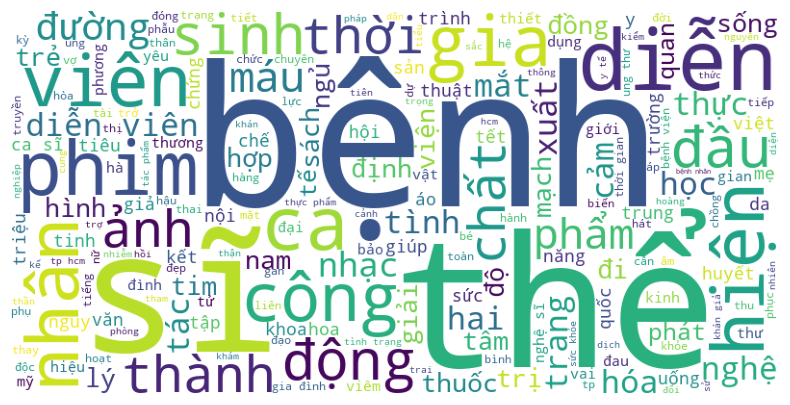

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Lấy tổng TF-IDF của mỗi từ
import numpy as np
tfidf_scores = np.asarray(X_text.sum(axis=0)).ravel()

# Lấy vocabulary
words = vectorizer.get_feature_names_out()

# Tạo dictionary word → score
word_scores = dict(zip(words, tfidf_scores))

# WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_scores)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

## 4. Mã hóa nhãn các nhóm

In [16]:
from sklearn.preprocessing import LabelEncoder

# Khởi tạo encoder
label_encoder = LabelEncoder()

# Encode cột group
y = label_encoder.fit_transform(df["group"])

# Kiểm tra mapping
print("Label mapping:")
for label, index in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "->", index)


Label mapping:
Giải trí -> 0
Sức khỏe -> 1


## 5. Xem phân bố trong không gian vector

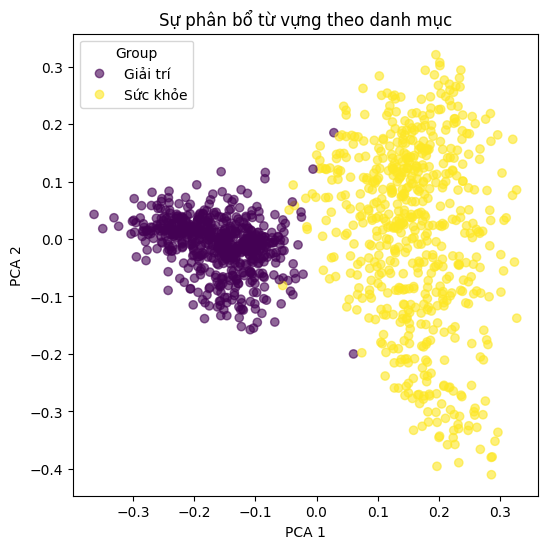

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# chuyển sparse -> dense
X_dense = X_text.toarray()

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# encode group thành số
groups = df["group"].astype("category")
colors = groups.cat.codes

# plot
plt.figure(figsize=(6,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=colors,
    alpha=0.6
)

# legend
handles, _ = scatter.legend_elements()
plt.legend(handles, list(groups.cat.categories), title="Group")

plt.title("Sự phân bổ từ vựng theo danh mục")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Sau khi thực hiện xong việc trực quan, ta nhận thấy các vector được phân nhóm khá rõ rệt

Vậy ta sẽ thực hiện bài toán theo hướng `classification` hay còn gọi là bài toán phân loại là phù hợp